# 01 — Data Cleaning & Pipeline

**Goal:** Load all Olist CSV files, merge them into a single master customer transaction table, handle data quality issues, and save a clean dataset for downstream analysis.

**Inputs:** Raw Olist CSV files in `../data/raw/`  
**Output:** `../data/cleaned/master_transactions.csv`

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

RAW_PATH = '../data/raw/'
CLEAN_PATH = '../data/cleaned/'
os.makedirs(CLEAN_PATH, exist_ok=True)

print('Libraries loaded successfully')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


## 2. Load Raw Data

In [3]:
# Load all Olist tables
orders       = pd.read_csv(RAW_PATH + 'olist_orders_dataset.csv')
order_items  = pd.read_csv(RAW_PATH + 'olist_order_items_dataset.csv')
customers    = pd.read_csv(RAW_PATH + 'olist_customers_dataset.csv')
payments     = pd.read_csv(RAW_PATH + 'olist_order_payments_dataset.csv')
products     = pd.read_csv(RAW_PATH + 'olist_products_dataset.csv')
reviews      = pd.read_csv(RAW_PATH + 'olist_order_reviews_dataset.csv')
category_map = pd.read_csv(RAW_PATH + 'product_category_name_translation.csv')

print('Tables loaded:')
for name, df in [('orders', orders), ('order_items', order_items),
                 ('customers', customers), ('payments', payments),
                 ('products', products), ('reviews', reviews)]:
    print(f'  {name}: {df.shape[0]:,} rows, {df.shape[1]} columns')

Tables loaded:
  orders: 99,441 rows, 8 columns
  order_items: 112,650 rows, 7 columns
  customers: 99,441 rows, 5 columns
  payments: 103,886 rows, 5 columns
  products: 32,951 rows, 9 columns
  reviews: 99,224 rows, 7 columns


## 3. Data Quality Check

In [4]:
def quality_report(df, name):
    """Print a concise data quality summary for a dataframe."""
    print(f'\n=== {name} ===')
    print(f'Shape: {df.shape}')
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f'Nulls:\n{nulls}')
    else:
        print('No nulls')
    print(f'Duplicates: {df.duplicated().sum()}')

for name, df in [('orders', orders), ('order_items', order_items),
                 ('customers', customers), ('payments', payments)]:
    quality_report(df, name)


=== orders ===
Shape: (99441, 8)
Nulls:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
Duplicates: 0

=== order_items ===
Shape: (112650, 7)
No nulls
Duplicates: 0

=== customers ===
Shape: (99441, 5)
No nulls
Duplicates: 0

=== payments ===
Shape: (103886, 5)
No nulls
Duplicates: 0


## 4. Clean & Prepare Each Table

In [5]:
# --- Orders: parse dates, keep only delivered orders ---
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders_clean = orders[orders['order_status'] == 'delivered'].copy()
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date'])

print(f'Delivered orders: {len(orders_clean):,} (from {len(orders):,} total)')

Delivered orders: 96,470 (from 99,441 total)


In [6]:
# --- Payments: aggregate to order level ---
payments_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max'),
    payment_type=('payment_type', lambda x: x.mode()[0])
).reset_index()

print(f'Payment records aggregated: {len(payments_agg):,} orders')

Payment records aggregated: 99,440 orders


In [7]:
# --- Products: translate category names to English ---
products_clean = products.merge(category_map, on='product_category_name', how='left')
products_clean['category_en'] = products_clean['product_category_name_english'].fillna('unknown')

# --- Order items: aggregate to order level ---
items_agg = order_items.merge(products_clean[['product_id', 'category_en']], on='product_id', how='left')
items_agg = items_agg.groupby('order_id').agg(
    item_count=('order_item_id', 'count'),
    total_freight=('freight_value', 'sum'),
    top_category=('category_en', lambda x: x.mode()[0] if len(x) > 0 else 'unknown')
).reset_index()

print(f'Order items aggregated: {len(items_agg):,} orders')

Order items aggregated: 98,666 orders


In [8]:
# --- Reviews: keep one review per order (latest) ---
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews_clean = reviews.sort_values('review_creation_date').drop_duplicates('order_id', keep='last')
reviews_clean = reviews_clean[['order_id', 'review_score']]

print(f'Reviews deduplicated: {len(reviews_clean):,} orders')

Reviews deduplicated: 98,673 orders


## 5. Build Master Transaction Table

In [9]:
# Merge everything into one master table
master = (
    orders_clean
    .merge(customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
    .merge(items_agg, on='order_id', how='left')
    .merge(reviews_clean, on='order_id', how='left')
)

# Rename for clarity
master = master.rename(columns={
    'order_purchase_timestamp': 'order_date',
    'order_delivered_customer_date': 'delivery_date',
    'customer_unique_id': 'customer_id_unique'
})

# Remove outliers: orders with zero or negative payment
master = master[master['total_payment'] > 0]

print(f'Master table shape: {master.shape}')
master.head()

Master table shape: (96469, 18)


,order_id,customer_id,order_status,order_date,order_approved_at,order_delivered_carrier_date,delivery_date,order_estimated_delivery_date,customer_id_unique,customer_state,customer_city,total_payment,payment_installments,payment_type,item_count,total_freight,top_category,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,38.71,1.00,voucher,1,8.72,housewares,4.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,barreiras,141.46,1.00,boleto,1,22.76,perfumery,4.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,179.12,3.00,credit_card,1,19.22,auto,5.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante,72.20,1.00,credit_card,1,27.20,pet_shop,5.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre,28.62,1.00,credit_card,1,8.72,stationery,5.00


## 6. Feature Engineering — Base Customer Metrics

In [10]:
# Set analysis snapshot date as one day after the last order
SNAPSHOT_DATE = master['order_date'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {SNAPSHOT_DATE.date()}')

# Build customer-level summary
customer_summary = master.groupby('customer_id_unique').agg(
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max'),
    order_count=('order_id', 'nunique'),
    total_spend=('total_payment', 'sum'),
    avg_order_value=('total_payment', 'mean'),
    avg_review_score=('review_score', 'mean'),
    top_category=('top_category', lambda x: x.mode()[0]),
    state=('customer_state', 'first')
).reset_index()

customer_summary['recency_days'] = (SNAPSHOT_DATE - customer_summary['last_order']).dt.days
customer_summary['tenure_days'] = (SNAPSHOT_DATE - customer_summary['first_order']).dt.days

print(f'Unique customers: {len(customer_summary):,}')
customer_summary.describe()

Snapshot date: 2018-08-30
Unique customers: 93,349


,first_order,last_order,order_count,total_spend,avg_order_value,avg_review_score,recency_days,tenure_days
count,93349,93349,93349.00,93349.00,93349.00,92746.00,93349.00,93349.00
mean,2018-01-01 12:13:34.723767,2018-01-04 03:43:00.423068,1.03,165.20,160.32,4.15,237.94,240.59
min,2016-10-03 09:44:50,2016-10-03 16:56:50,1.00,9.59,9.59,1.00,1.00,1.00
25%,2017-09-13 15:34:04,2017-09-17 18:24:36,1.00,63.05,62.37,4.00,114.00,117.00
50%,2018-01-20 03:25:12,2018-01-22 23:58:22,1.00,107.78,105.63,5.00,219.00,222.00
75%,2018-05-05 13:57:37,2018-05-07 16:58:08,1.00,182.55,176.65,5.00,346.00,350.00
max,2018-08-29 15:00:37,2018-08-29 15:00:37,15.00,13664.08,13664.08,5.00,695.00,696.00
std,NaN,NaN,0.21,226.32,219.58,1.28,152.58,153.09


## 7. Save Cleaned Data

In [11]:
master.to_csv(CLEAN_PATH + 'master_transactions.csv', index=False)
customer_summary.to_csv(CLEAN_PATH + 'customer_summary.csv', index=False)

print('Saved:')
print(f'  master_transactions.csv  — {len(master):,} rows')
print(f'  customer_summary.csv     — {len(customer_summary):,} rows')

Saved:
  master_transactions.csv  — 96,469 rows
  customer_summary.csv     — 93,349 rows


## 8. Quick EDA — Revenue & Order Trends

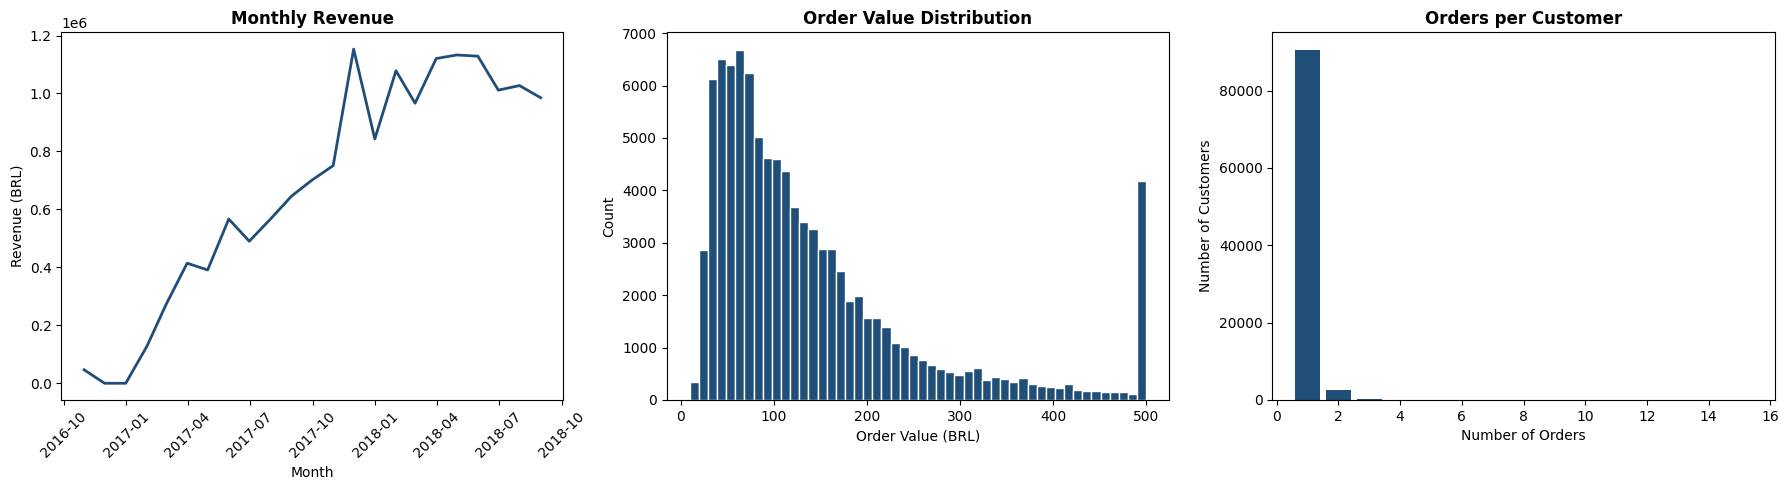

EDA chart saved to reports/


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monthly revenue
monthly = master.set_index('order_date').resample('ME')['total_payment'].sum()
axes[0].plot(monthly.index, monthly.values, color='#1F4E79', linewidth=2)
axes[0].set_title('Monthly Revenue', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (BRL)')
axes[0].tick_params(axis='x', rotation=45)

# Order value distribution
axes[1].hist(master['total_payment'].clip(upper=500), bins=50, color='#1F4E79', edgecolor='white')
axes[1].set_title('Order Value Distribution', fontweight='bold')
axes[1].set_xlabel('Order Value (BRL)')
axes[1].set_ylabel('Count')

# Orders per customer
order_counts = customer_summary['order_count'].value_counts().sort_index().head(10)
axes[2].bar(order_counts.index, order_counts.values, color='#1F4E79')
axes[2].set_title('Orders per Customer', fontweight='bold')
axes[2].set_xlabel('Number of Orders')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('../reports/01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA chart saved to reports/')

## Summary

| Metric | Value |
|---|---|
| Total delivered orders | *(fill in)* |
| Unique customers | *(fill in)* |
| Date range | *(fill in)* |
| Avg order value (BRL) | *(fill in)* |
| Repeat purchase rate | *(fill in)* |

**Next:** Run `02_rfm_segmentation.ipynb`